In [1]:
%matplotlib inline

import pathlib

import numpy as np
import matplotlib.pyplot as plt

from rtlsdr_receiver_flowgraph import rtlsdr_receiver_flowgraph

# Some nice defaults for figures
plt.rcParams['figure.figsize'] = (7, 3.5)
plt.rcParams['figure.facecolor'] = 'w'

In [2]:
# Example of how to run the flowgraph
fg = rtlsdr_receiver_flowgraph(duration=3, iq_file_output='/tmp/reu-recording')
fg.run()

gr-osmosdr 0.2.0.0 (0.2.0) gnuradio 3.10.12.0
built-in source types: file rtl rtl_tcp uhd hackrf bladerf rfspace airspy soapy redpitaya 
[INFO] [UHD] linux; GNU C++ version 15.2.1 20260209; Boost_109100; DPDK_25.11; UHD_4.9.0.makepkg-0-g9ec1f582
Found Rafael Micro R820T tuner
Using device #0 Realtek RTL2838UHIDIR SN: 00000001
Found Rafael Micro R820T tuner
[R82XX] PLL not locked!
[R82XX] PLL not locked!


log :info: Generating /tmp/reu-recording.sigmf-meta, writing SigMF data to /tmp/reu-recording.sigmf-data


In [3]:
# We have access to the Vector Sink as a Python object
fg.spectrum_vector_sink

In [4]:
# We can fetch the data
# Documentation:
# https://wiki.gnuradio.org/index.php/Vector_Sink
# https://github.com/gnuradio/gnuradio/blob/main/gr-blocks/include/gnuradio/blocks/vector_sink.h
fg.spectrum_vector_sink.data()

[0.280815064907074,
 0.23748227953910828,
 0.20947527885437012,
 0.24459238350391388,
 0.19763097167015076,
 0.20673708617687225,
 0.22872373461723328,
 0.3030449450016022,
 0.36724600195884705,
 0.27343398332595825,
 0.23199179768562317,
 0.2354961782693863,
 0.1968344897031784,
 0.17343561351299286,
 0.21167337894439697,
 0.24757881462574005,
 0.22374285757541656,
 0.2140391767024994,
 0.18316958844661713,
 0.2290162444114685,
 0.30168336629867554,
 0.24891401827335358,
 0.20986416935920715,
 0.19228321313858032,
 0.1992461085319519,
 0.27415940165519714,
 0.29628804326057434,
 0.2338189035654068,
 0.21329838037490845,
 0.20877398550510406,
 0.19401754438877106,
 0.24344223737716675,
 0.2594926059246063,
 0.250925749540329,
 0.23509423434734344,
 0.23222258687019348,
 0.23587654531002045,
 0.2196444869041443,
 0.26640763878822327,
 0.29007357358932495,
 0.263650119304657,
 0.19887372851371765,
 0.19066087901592255,
 0.24507726728916168,
 0.23731905221939087,
 0.26238712668418884,
 0.

In [5]:
# Convert spectrum sink data to a numpy array
spectrum = np.array(fg.spectrum_vector_sink.data()).reshape(-1, fg.nfft)
spectrum.shape

(2, 65536)

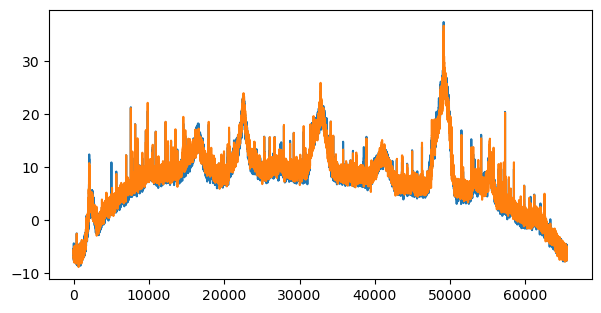

In [6]:
plt.plot(10 * np.log10(spectrum[0]))
plt.plot(10 * np.log10(spectrum[1]))

In [7]:
# Destroy the flowgraph to release access to the RTL-SDR
del fg

In [8]:
# An example "observation"

frequencies_to_scan = [98e6, 95.5e6, 117.5e6, 425e6, 801e6, 935e6, 1090e6]
freq_xlating_freqs = [800e3, 300e3, -200e3, -250e3, 300e3, 200e3, 0]
decimations = [12, 12, 64, 16, 8, 8, 1]
duration = 10

spectrum_data = {}
output_dir = pathlib.Path('/tmp/observation')
output_dir.mkdir(exist_ok=True)

for rf_freq, xlating_freq, decimation in zip(frequencies_to_scan, freq_xlating_freqs, decimations):
    print(f'Receiving on {rf_freq * 1e-6:.3f} MHz (tune to {xlating_freq*1e-3:.1f} kHz)')
    iq_file = str(output_dir / f'iq_data_{rf_freq * 1e-6:.3f}')
    # move antennas? set up LNAs?
    fg = rtlsdr_receiver_flowgraph(
        duration=duration, frequency=rf_freq, freq_xlating_frequency=xlating_freq,
        decimation=decimation, iq_file_output=iq_file)
    fg.run()
    spectrum_data[rf_freq] = np.array(fg.spectrum_vector_sink.data()).reshape(-1, fg.nfft)
    del fg

Receiving on 98.000 MHz (tune to 800.0 kHz)
log :info: Generating /tmp/observation/iq_data_98.000.sigmf-meta, writing SigMF data to /tmp/observation/iq_data_98.000.sigmf-data


gr-osmosdr 0.2.0.0 (0.2.0) gnuradio 3.10.12.0
built-in source types: file rtl rtl_tcp uhd hackrf bladerf rfspace airspy soapy redpitaya 
Using device #0 Realtek RTL2838UHIDIR SN: 00000001
Found Rafael Micro R820T tuner
[R82XX] PLL not locked!
[R82XX] PLL not locked!


Receiving on 95.500 MHz (tune to 300.0 kHz)
log :info: Generating /tmp/observation/iq_data_95.500.sigmf-meta, writing SigMF data to /tmp/observation/iq_data_95.500.sigmf-data


gr-osmosdr 0.2.0.0 (0.2.0) gnuradio 3.10.12.0
built-in source types: file rtl rtl_tcp uhd hackrf bladerf rfspace airspy soapy redpitaya 
Using device #0 Realtek RTL2838UHIDIR SN: 00000001
Found Rafael Micro R820T tuner
[R82XX] PLL not locked!
[R82XX] PLL not locked!


Receiving on 117.500 MHz (tune to -200.0 kHz)
log :info: Generating /tmp/observation/iq_data_117.500.sigmf-meta, writing SigMF data to /tmp/observation/iq_data_117.500.sigmf-data


...

gr-osmosdr 0.2.0.0 (0.2.0) gnuradio 3.10.12.0
built-in source types: file rtl rtl_tcp uhd hackrf bladerf rfspace airspy soapy redpitaya 
Using device #0 Realtek RTL2838UHIDIR SN: 00000001
Found Rafael Micro R820T tuner
[R82XX] PLL not locked!
[R82XX] PLL not locked!


Receiving on 935.000 MHz (tune to 200.0 kHz)
log :info: Generating /tmp/observation/iq_data_935.000.sigmf-meta, writing SigMF data to /tmp/observation/iq_data_935.000.sigmf-data


gr-osmosdr 0.2.0.0 (0.2.0) gnuradio 3.10.12.0
built-in source types: file rtl rtl_tcp uhd hackrf bladerf rfspace airspy soapy redpitaya 
Using device #0 Realtek RTL2838UHIDIR SN: 00000001
Found Rafael Micro R820T tuner
[R82XX] PLL not locked!
[R82XX] PLL not locked!


Receiving on 1090.000 MHz (tune to 0.0 kHz)
log :info: Generating /tmp/observation/iq_data_1090.000.sigmf-meta, writing SigMF data to /tmp/observation/iq_data_1090.000.sigmf-data


gr-osmosdr 0.2.0.0 (0.2.0) gnuradio 3.10.12.0
built-in source types: file rtl rtl_tcp uhd hackrf bladerf rfspace airspy soapy redpitaya 
Using device #0 Realtek RTL2838UHIDIR SN: 00000001
Found Rafael Micro R820T tuner
[R82XX] PLL not locked!
[R82XX] PLL not locked!


In [9]:
spectrum_data

{98000000.0: array([[0.21672697, 0.26036805, 0.2428184 , ..., 0.22845925, 0.21735629,
         0.20435412],
        [0.22917005, 0.20839329, 0.20725162, ..., 0.19947149, 0.18292314,
         0.19864915],
        [0.19236617, 0.2425918 , 0.22570981, ..., 0.19082269, 0.20106167,
         0.17350529],
        ...,
        [0.19545196, 0.17892608, 0.18344851, ..., 0.16459268, 0.19406462,
         0.19966179],
        [0.23629464, 0.27668902, 0.24449533, ..., 0.18665987, 0.17672209,
         0.18958841],
        [0.21336402, 0.21780206, 0.24264275, ..., 0.24878906, 0.2415245 ,
         0.2267338 ]], shape=(9, 65536)),
 95500000.0: array([[0.23337142, 0.23661403, 0.32216388, ..., 0.3356283 , 0.33532363,
         0.29276994],
        [0.22414102, 0.2608076 , 0.29613802, ..., 0.32509768, 0.31451878,
         0.26704541],
        [0.30696771, 0.28819788, 0.26240113, ..., 0.33992758, 0.31651065,
         0.243811  ],
        ...,
        [0.33216706, 0.31684873, 0.24734955, ..., 0.24275337, 0.26

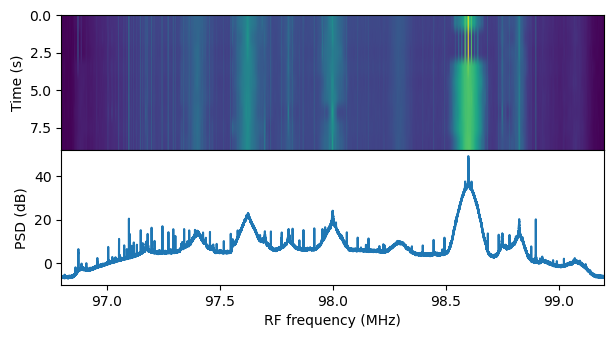

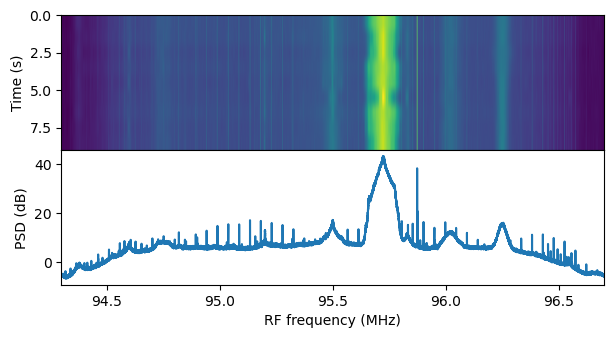

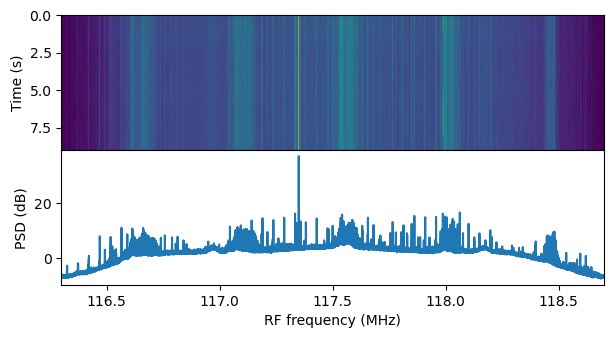

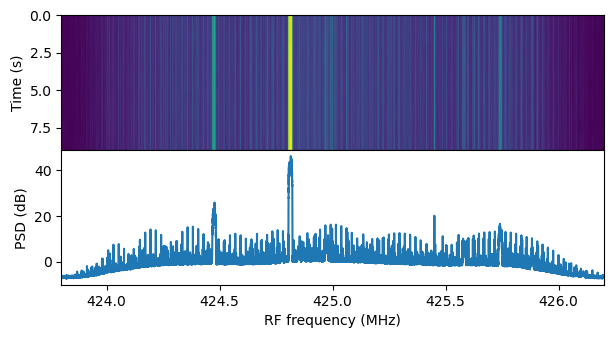

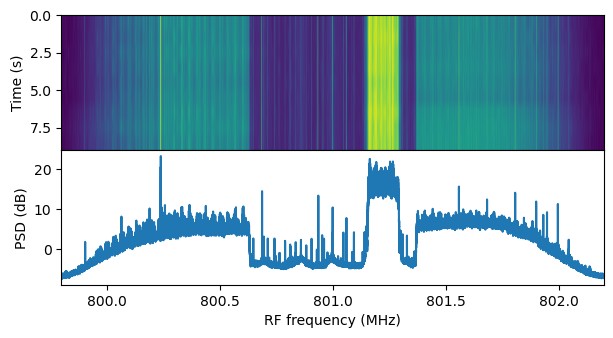

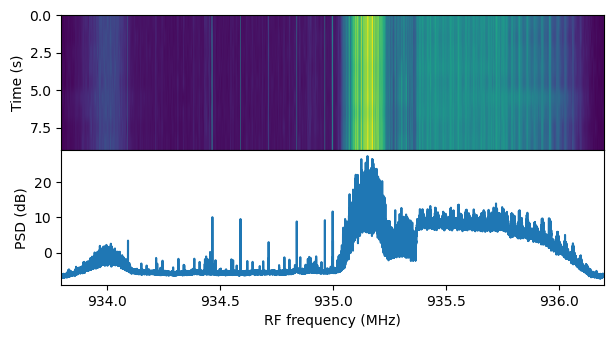

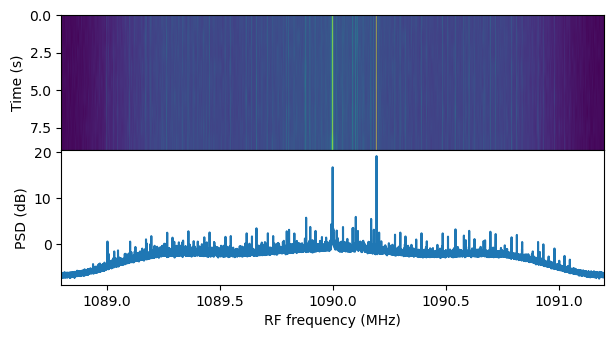

In [10]:
# Display the results
samp_rate = 2.4e6
waterfall_freq_reduce = 64
for freq, data in spectrum_data.items():  
    freq_axis = np.fft.fftshift(np.fft.fftfreq(data.shape[1], 1 / samp_rate))
    fig, axs = plt.subplots(2, 1, sharex=True)
    waterfall = np.max(data.reshape(data.shape[0], -1, waterfall_freq_reduce), axis=-1)
    axs[0].imshow(10*np.log10(waterfall), aspect='auto',
                  extent=[1e-6 * (freq - samp_rate/2), 1e-6 * (freq + samp_rate/2),
                          data.shape[0], 0])
    axs[1].plot(1e-6 * (freq_axis + freq), 10*np.log10(np.average(data, axis=0)))
    plt.subplots_adjust(hspace=0)
    axs[1].set_xlabel('RF frequency (MHz)')
    axs[1].set_ylabel('PSD (dB)')
    axs[0].set_ylabel('Time (s)')